In [3]:
#pip install pandas matplotlib scipy numpy seaborn scikit-learn lightgbm xgboost

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chisquare
import numpy as np
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier, BaggingClassifier, VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [40]:
file_path = "SuperStore_Orders.csv"
df = pd.read_csv(file_path, encoding='ISO-8859-1')

In [41]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01-01-2011,06-01-2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,01-01-2011,05-01-2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,01-01-2011,05-01-2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [42]:
df.shape

(51290, 21)

In [44]:
def categorize_profit(profit):
    if profit <= 0:
        return 'Rugi'
    elif profit <= 100:
        return 'Untung Kecil'
    else:
        return 'Untung Besar'

df['profit_level'] = df['profit'].apply(categorize_profit)


C:\Users\71485\AppData\Local\Temp\ipykernel_16892\88992214.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=profit_counts_sorted.index,


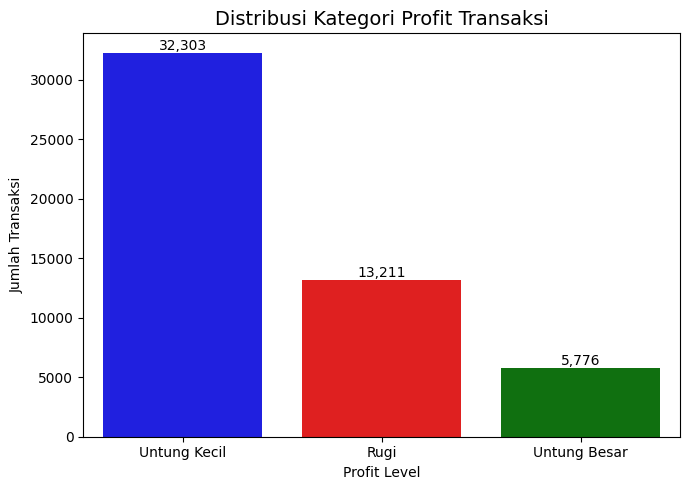

In [45]:
# Hitung jumlah kategori profit
profit_counts = df['profit_level'].value_counts()

# Urutkan secara ascending (dari jumlah paling sedikit ke paling banyak)
profit_counts_sorted = profit_counts.sort_values(ascending=False)

# Bikin warna sesuai kategori
color_map = {'Rugi': 'red', 'Untung Kecil': 'blue', 'Untung Besar': 'green'}
colors = [color_map[label] for label in profit_counts_sorted.index]

# Plot grafik batang
plt.figure(figsize=(7, 5))
bars = sns.barplot(x=profit_counts_sorted.index,
                   y=profit_counts_sorted.values,
                   palette=colors)

# Tambahkan angka di atas setiap batang
for bar in bars.patches:
    bars.annotate(format(int(bar.get_height()), ','),
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha='center', va='bottom', fontsize=10)

# Tambahkan judul dan label sumbu
plt.title('Distribusi Kategori Profit Transaksi', fontsize=14)
plt.xlabel('Profit Level')
plt.ylabel('Jumlah Transaksi')
plt.tight_layout()
plt.show()


In [46]:
df[['category', 'sub_category', 'segment', 'region', 'quantity', 'discount', 'profit', 'profit_level']].head()


,category,sub_category,segment,region,quantity,discount,profit,profit_level
0,Office Supplies,Storage,Consumer,Africa,2,0.0,106.140,Untung Besar
1,Office Supplies,Supplies,Consumer,Oceania,3,0.1,36.036,Untung Kecil
2,Office Supplies,Storage,Consumer,EMEA,4,0.0,29.640,Untung Kecil
3,Office Supplies,Paper,Home Office,North,3,0.5,-26.055,Rugi
4,Furniture,Furnishings,Consumer,Oceania,5,0.1,37.770,Untung Kecil


In [47]:
# Binning kolom discount
df['discount_bin'] = pd.cut(
    df['discount'],
    bins=[-0.01, 0, 0.2, 0.5, float('inf')],
    labels=['Tanpa Diskon', 'Diskon Rendah', 'Diskon Sedang', 'Diskon Besar']
)

# Binning kolom quantity
df['quantity_bin'] = pd.cut(
    df['quantity'],
    bins=[0, 2, 5, float('inf')],
    labels=['Sedikit', 'Sedang', 'Banyak']
)

# Binning kolom shipping_cost
df['shipping_cost_bin'] = pd.cut(
    df['shipping_cost'],
    bins=[-0.1, 10, 50, float('inf')],
    labels=['Murah', 'Sedang', 'Mahal']
)

In [48]:
# Cek hasil binning
print(df[['discount', 'discount_bin', 'quantity', 'quantity_bin', 'shipping_cost', 'shipping_cost_bin']].head())

   discount   discount_bin  quantity quantity_bin  shipping_cost  \
0       0.0   Tanpa Diskon         2      Sedikit          35.46   
1       0.1  Diskon Rendah         3       Sedang           9.72   
2       0.0   Tanpa Diskon         4       Sedang           8.17   
3       0.5  Diskon Sedang         3       Sedang           4.82   
4       0.1  Diskon Rendah         5       Sedang           4.70   

  shipping_cost_bin  
0            Sedang  
1             Murah  
2             Murah  
3             Murah  
4             Murah  


In [49]:
# Pilih fitur-fitur kategorikal + target
categorical_features = [
    'category', 'sub_category', 'segment', 'region',
    'order_priority', 'discount_bin', 'quantity_bin', 'shipping_cost_bin'
]

# Copy data yang diperlukan dan encode ke angka
df_encoded = df[categorical_features + ['profit_level']].copy()
label_encoders = {}

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# Pisahkan fitur dan target
X = df_encoded[categorical_features]
y = df_encoded['profit_level']

# Jalankan uji chi-squared
chi_scores, p_values = chi2(X, y)

# Buat dataframe hasilnya
chi2_results = pd.DataFrame({
    'Feature': categorical_features,
    'Chi2 Score': chi_scores,
    'p-value': p_values
}).sort_values(by='Chi2 Score', ascending=False)

# Tampilkan hasil
print(chi2_results)

             Feature   Chi2 Score        p-value
5       discount_bin  7499.915749   0.000000e+00
7  shipping_cost_bin  1148.086589  4.967809e-250
6       quantity_bin   854.722692  2.507990e-186
1       sub_category   126.952560   2.707708e-28
0           category   119.482580   1.134194e-26
3             region    79.384885   5.778183e-18
2            segment     2.980944   2.252664e-01
4     order_priority     0.700761   7.044201e-01


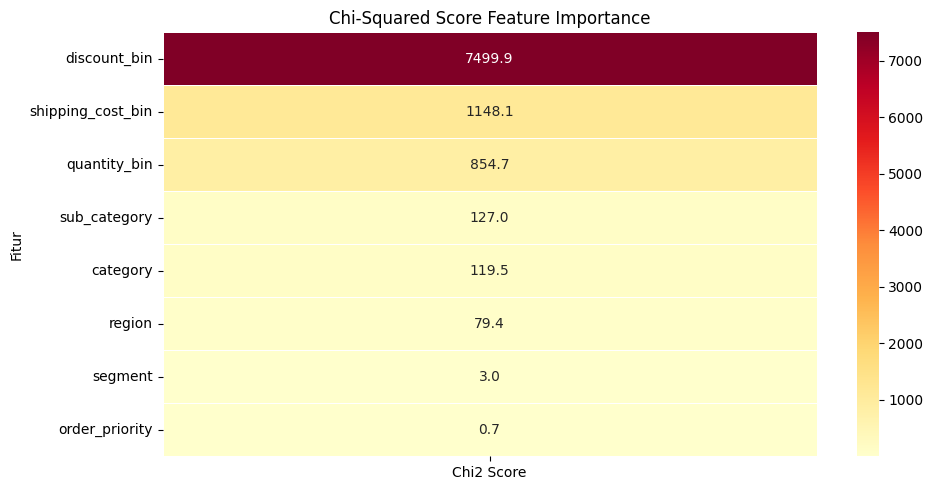

In [50]:
# Siapkan data heatmap dari hasil chi2
heatmap_data = chi2_results.set_index('Feature')[['Chi2 Score']]

# Plot heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)

# Tambahkan judul dan label
plt.title("Chi-Squared Score Feature Importance")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

In [51]:
from sklearn.ensemble import RandomForestClassifier

# Fitur yang akan digunakan (termasuk hasil binning)
selected_features = [
    'category', 'sub_category', 'segment', 'region',
    'order_priority', 'discount_bin', 'quantity_bin', 'shipping_cost_bin'
]

# Encode fitur dan target jadi angka
X = df[selected_features].apply(LabelEncoder().fit_transform)
y = LabelEncoder().fit_transform(df['profit_level'])

# Split data jadi training dan testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Buat dan latih model Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Ambil feature importance dari model
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("=== Feature Importance dari Random Forest ===")
print(feature_importance)

# Evaluasi performa model
y_pred = rf.predict(X_test)
report = classification_report(y_test, y_pred)
print("\n=== Classification Report ===")
print(report)

=== Feature Importance dari Random Forest ===
             Feature  Importance
5       discount_bin    0.497485
3             region    0.143706
7  shipping_cost_bin    0.123942
1       sub_category    0.089333
4     order_priority    0.042835
2            segment    0.038042
6       quantity_bin    0.034791
0           category    0.029866

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.84      0.79      0.81      2642
           1       0.60      0.54      0.57      1155
           2       0.86      0.89      0.88      6461

    accuracy                           0.83     10258
   macro avg       0.77      0.74      0.75     10258
weighted avg       0.82      0.83      0.83     10258



C:\Users\71485\AppData\Local\Temp\ipykernel_16892\3607774496.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


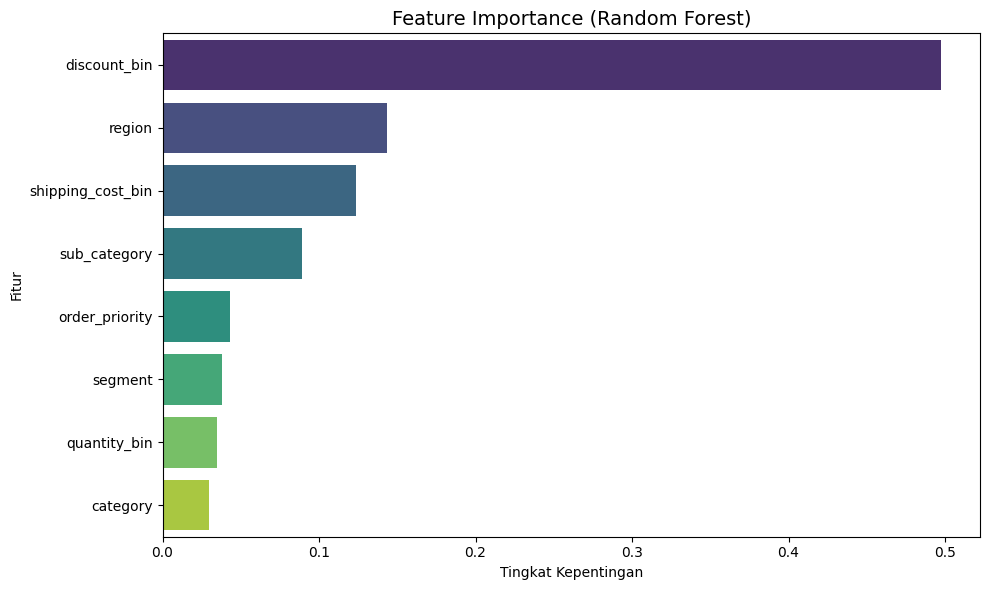

In [52]:
# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    palette='viridis'
)

# Tambahkan judul dan label
plt.title('Feature Importance (Random Forest)', fontsize=14)
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

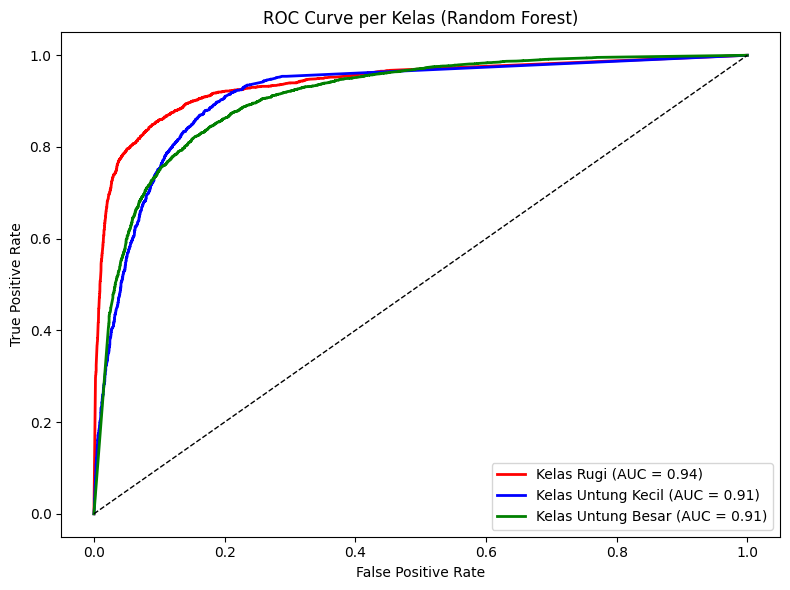

In [53]:
# Binarize target untuk multiclass ROC
y_bin = label_binarize(y, classes=[0, 1, 2])
n_classes = y_bin.shape[1]

# Split ulang untuk jaga-jaga
X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y)

# One-vs-rest classifier
classifier = OneVsRestClassifier(RandomForestClassifier(random_state=42))
classifier.fit(X_train, y_train_bin)
y_score = classifier.predict_proba(X_test)

# ROC Curve
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green']
labels = ['Rugi', 'Untung Kecil', 'Untung Besar']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Kelas {labels[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Kelas (Random Forest)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [54]:
# Label kelas (ubah sesuai urutan kamu di y)
labels = ['Rugi', 'Untung Kecil', 'Untung Besar']

# Buat dataframe AUC per kelas
auc_table = pd.DataFrame({
    'Kelas': labels,
    'ROC AUC': [roc_auc[i] for i in range(len(labels))]
})

# Tampilkan hasilnya
print("=== ROC AUC Score per Kelas ===")
print(auc_table)

=== ROC AUC Score per Kelas ===
          Kelas   ROC AUC
0          Rugi  0.939824
1  Untung Kecil  0.913114
2  Untung Besar  0.909562


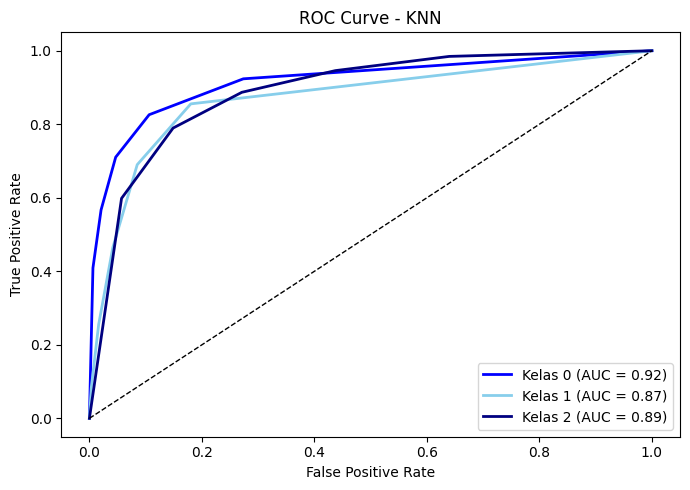

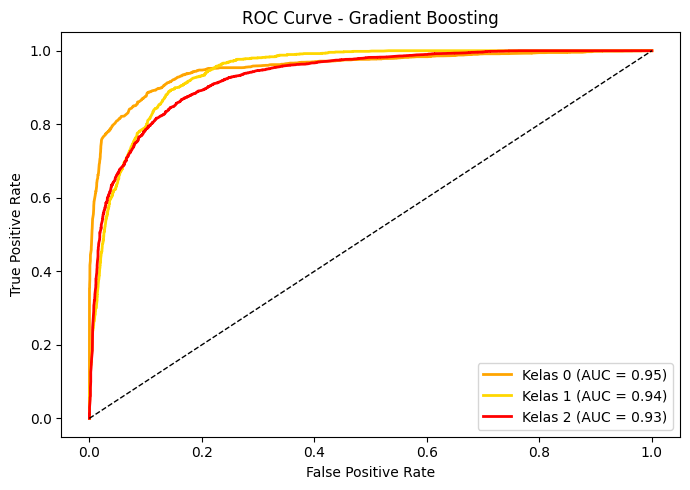

=== ROC AUC - KNN ===
          Kelas   ROC AUC
0          Rugi  0.915669
1  Untung Kecil  0.870540
2  Untung Besar  0.888395

=== ROC AUC - Gradient Boosting ===
          Kelas   ROC AUC
0          Rugi  0.953963
1  Untung Kecil  0.942386
2  Untung Besar  0.929019

=== Feature Importance - Gradient Boosting ===
             Feature  Importance
5       discount_bin    0.984323
3             region    0.006638
1       sub_category    0.006254
0           category    0.002648
7  shipping_cost_bin    0.000080
4     order_priority    0.000051
6       quantity_bin    0.000003
2            segment    0.000003


In [55]:
def evaluate_model(model, model_name, color):
    clf = OneVsRestClassifier(model)
    clf.fit(X_train, y_train_bin)
    y_score = clf.predict_proba(X_test)

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(3):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # === Grafik ROC ===
    plt.figure(figsize=(7, 5))
    for i in range(3):
        plt.plot(fpr[i], tpr[i], label=f'Kelas {i} (AUC = {roc_auc[i]:.2f})', lw=2, color=color[i])
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.title(f'ROC Curve - {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # === Tabel AUC ===
    auc_table = pd.DataFrame({
        'Kelas': ['Rugi', 'Untung Kecil', 'Untung Besar'],
        'ROC AUC': [roc_auc[i] for i in range(3)]
    })

    # === Feature Importance === (hanya jika ada)
    if hasattr(clf.estimators_[0], 'feature_importances_'):
        fi_table = pd.DataFrame({
            'Feature': X.columns,
            'Importance': clf.estimators_[0].feature_importances_
        }).sort_values(by='Importance', ascending=False)
        return auc_table, fi_table
    else:
        return auc_table, None

# === Evaluasi Model KNN dan Gradient Boosting ===
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

colors = [['blue', 'skyblue', 'navy'], ['orange', 'gold', 'red']]

auc_knn, _ = evaluate_model(KNeighborsClassifier(n_neighbors=5), 'KNN', colors[0])
auc_gb, fi_gb = evaluate_model(GradientBoostingClassifier(random_state=42), 'Gradient Boosting', colors[1])

# === Print Tabel ===
print("=== ROC AUC - KNN ===")
print(auc_knn)

print("\n=== ROC AUC - Gradient Boosting ===")
print(auc_gb)
print("\n=== Feature Importance - Gradient Boosting ===")
print(fi_gb)


C:\Users\71485\AppData\Local\Temp\ipykernel_16892\233240160.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_gb, x='Importance', y='Feature', palette='viridis')


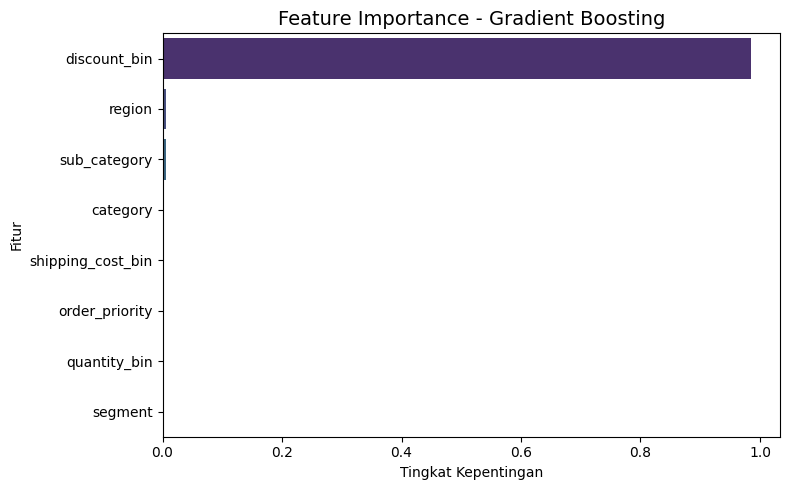

In [56]:
# Plot feature importance
plt.figure(figsize=(8, 5))
sns.barplot(data=fi_gb, x='Importance', y='Feature', palette='viridis')

plt.title('Feature Importance - Gradient Boosting', fontsize=14)
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,000404 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 50
[LightGBM] [Info] Number of data points in the train set: 41032, number of used features: 8
[LightGBM] [Info] Start training from score -0,297839
[LightGBM] [Info] Start training from score -1,356427
[LightGBM] [Info] Start training from score -34,538776
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,000465 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 50
[LightGBM] [Info] Number of data points in the train set: 41032, number of used features: 8
[LightGBM] [Info] Start training from score -0,119481
[LightGBM] [Info] Start training from score -2,183741
[LightGBM] [Info] Start train

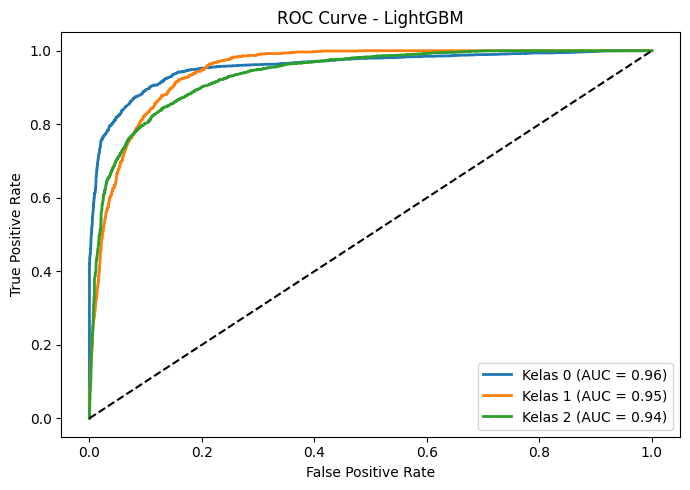

=== ROC AUC LightGBM ===
          Kelas   ROC AUC
0          Rugi  0.957442
1  Untung Kecil  0.947752
2  Untung Besar  0.935018
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,000414 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 50
[LightGBM] [Info] Number of data points in the train set: 51290, number of used features: 8
[LightGBM] [Info] Start training from score -1,356446
[LightGBM] [Info] Start training from score -2,183784
[LightGBM] [Info] Start training from score -0,462336


C:\Users\71485\AppData\Local\Temp\ipykernel_16892\4143780067.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')


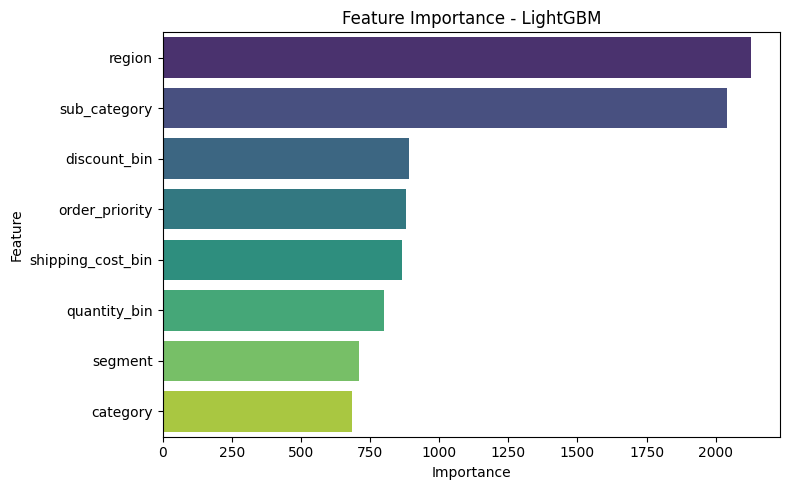

In [57]:
# Split data
X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y)

# ===== MODEL LIGHTGBM =====
lgb_model = LGBMClassifier(objective='multiclass', num_class=3, random_state=42)
clf = OneVsRestClassifier(lgb_model)
clf.fit(X_train, y_train_bin)

# ===== ROC AUC =====
y_score = clf.predict_proba(X_test)
fpr, tpr, roc_auc = {}, {}, {}
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve
plt.figure(figsize=(7, 5))
for i in range(3):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Kelas {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ===== AUC Table =====
auc_lgb = pd.DataFrame({
    'Kelas': ['Rugi', 'Untung Kecil', 'Untung Besar'],
    'ROC AUC': [roc_auc[i] for i in range(3)]
})
print("=== ROC AUC LightGBM ===")
print(auc_lgb)

# ===== FEATURE IMPORTANCE =====
model_single = LGBMClassifier(objective='multiclass', num_class=3, random_state=42)
model_single.fit(X, y)  # dilatih ulang tanpa one-vs-rest agar bisa akses importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_single.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - LightGBM')
plt.tight_layout()
plt.show()

In [58]:
# Print tabel feature importance dari LightGBM (yang sudah kamu latih ulang sebagai model_single)
print("=== Feature Importance - LightGBM ===")
print(feature_importance)


=== Feature Importance - LightGBM ===
             Feature  Importance
3             region        2126
1       sub_category        2039
5       discount_bin         892
4     order_priority         881
7  shipping_cost_bin         864
6       quantity_bin         800
2            segment         712
0           category         686


In [59]:
from sklearn.metrics import accuracy_score

# --- KNN ---
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train_bin.argmax(axis=1))
y_pred_knn = knn_model.predict(X_test)
acc_knn = accuracy_score(y_test_bin.argmax(axis=1), y_pred_knn)

# --- Gradient Boosting ---
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train_bin.argmax(axis=1))
y_pred_gb = gb_model.predict(X_test)
acc_gb = accuracy_score(y_test_bin.argmax(axis=1), y_pred_gb)

# --- LightGBM ---
lgb_model_acc = LGBMClassifier(objective='multiclass', num_class=3, random_state=42)
lgb_model_acc.fit(X_train, y_train_bin.argmax(axis=1))
y_pred_lgb = lgb_model_acc.predict(X_test)
acc_lgb = accuracy_score(y_test_bin.argmax(axis=1), y_pred_lgb)

# --- Print All ---
print("=== Akurasi Tiap Model ===")
print(f"KNN Accuracy              : {acc_knn:.4f}")
print(f"Gradient Boosting Accuracy: {acc_gb:.4f}")
print(f"LightGBM Accuracy         : {acc_lgb:.4f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,000356 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 50
[LightGBM] [Info] Number of data points in the train set: 41032, number of used features: 8
[LightGBM] [Info] Start training from score -1,356427
[LightGBM] [Info] Start training from score -2,183741
[LightGBM] [Info] Start training from score -0,462351
=== Akurasi Tiap Model ===
KNN Accuracy              : 0.8081
Gradient Boosting Accuracy: 0.8501
LightGBM Accuracy         : 0.8518


c:\Users\71485\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:01:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\71485\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:01:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\71485\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:01:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


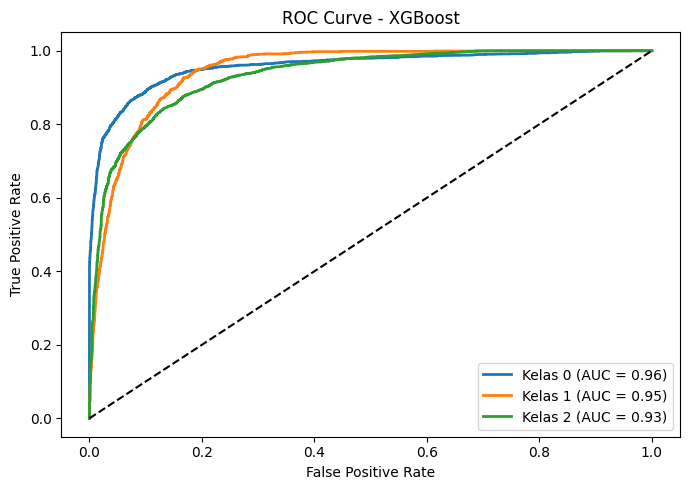

=== ROC AUC - XGBoost ===
          Kelas   ROC AUC
0          Rugi  0.957400
1  Untung Kecil  0.945230
2  Untung Besar  0.933034


c:\Users\71485\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:01:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\71485\AppData\Local\Temp\ipykernel_16892\3764270105.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_xgb, x='Importance', y='Feature', palette='viridis')


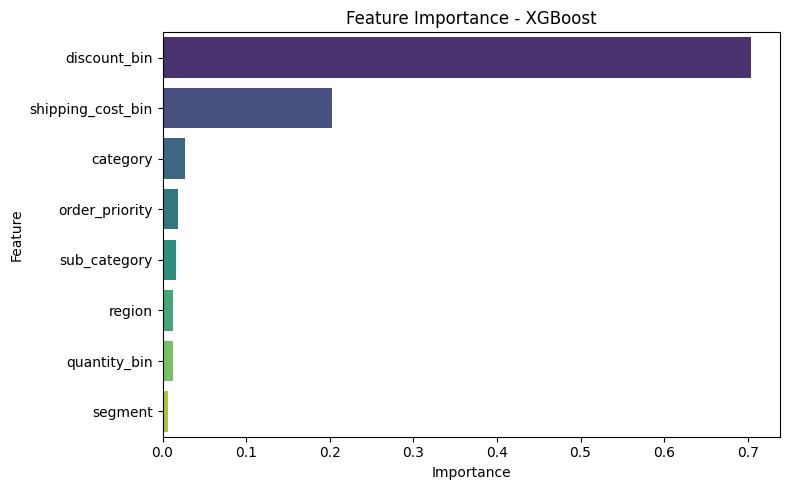


=== Akurasi XGBoost: 0.8692


In [60]:
# ===== LATIH MODEL (OneVsRest untuk ROC AUC) =====
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', objective='multi:softprob', num_class=3, random_state=42)
xgb_ovr = OneVsRestClassifier(xgb_model)
xgb_ovr.fit(X_train, y_train_bin)

# ===== ROC AUC =====
y_score_xgb = xgb_ovr.predict_proba(X_test)
fpr_xgb, tpr_xgb, roc_auc_xgb = {}, {}, {}
for i in range(3):
    fpr_xgb[i], tpr_xgb[i], _ = roc_curve(y_test_bin[:, i], y_score_xgb[:, i])
    roc_auc_xgb[i] = auc(fpr_xgb[i], tpr_xgb[i])

# ROC Curve Plot
plt.figure(figsize=(7, 5))
for i in range(3):
    plt.plot(fpr_xgb[i], tpr_xgb[i], lw=2, label=f'Kelas {i} (AUC = {roc_auc_xgb[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - XGBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ROC AUC Table
auc_xgb = pd.DataFrame({
    'Kelas': ['Rugi', 'Untung Kecil', 'Untung Besar'],
    'ROC AUC': [roc_auc_xgb[i] for i in range(3)]
})
print("=== ROC AUC - XGBoost ===")
print(auc_xgb)

# ===== FEATURE IMPORTANCE =====
# Latih ulang tanpa OneVsRest agar bisa akses .feature_importances_
xgb_model_fit = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', objective='multi:softprob', num_class=3, random_state=42)
xgb_model_fit.fit(X, y)

fi_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model_fit.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(8, 5))
sns.barplot(data=fi_xgb, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

# ===== ACCURACY =====
# Prediksi dengan model satuan (bukan OneVsRest)
y_pred_xgb = xgb_model_fit.predict(X_test)
acc_xgb = accuracy_score(y_test_bin.argmax(axis=1), y_pred_xgb)

print(f"\n=== Akurasi XGBoost: {acc_xgb:.4f}")

In [61]:
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model_fit.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("=== Feature Importance - XGBoost ===")
print(feature_importance_xgb)


=== Feature Importance - XGBoost ===
             Feature  Importance
5       discount_bin    0.703466
7  shipping_cost_bin    0.203095
0           category    0.026372
4     order_priority    0.017928
1       sub_category    0.016450
3             region    0.013057
6       quantity_bin    0.012770
2            segment    0.006862


In [62]:
# Prediksi hasil untuk test set (dengan model XGBClassifier, bukan OneVsRest)
y_pred = xgb_model_fit.predict(X_test)

# Mapping angka ke label
label_map = {0: 'Rugi', 1: 'Untung Kecil', 2: 'Untung Besar'}

# Gabungkan prediksi dan data aslinya
hasil_prediksi = X_test.copy()
hasil_prediksi['Prediksi Profit'] = y_pred
hasil_prediksi['Prediksi Profit'] = hasil_prediksi['Prediksi Profit'].replace(label_map)


In [63]:
# Ambil data fitur asli dari df yang belum di-encode
decoded_df = df.loc[X_test.index, selected_features].copy()
decoded_df['Prediksi Profit'] = hasil_prediksi['Prediksi Profit']


In [64]:
untung_besar = decoded_df[decoded_df['Prediksi Profit'] == 'Untung Besar']
untung_kecil = decoded_df[decoded_df['Prediksi Profit'] == 'Untung Kecil']
rugi = decoded_df[decoded_df['Prediksi Profit'] == 'Rugi']


In [65]:
untung_besar['discount_bin'].value_counts(normalize=True)
untung_besar['segment'].value_counts(normalize=True)


segment
Consumer       0.520913
Corporate      0.294531
Home Office    0.184557
Name: proportion, dtype: float64

In [66]:
rugi['shipping_cost_bin'].value_counts(normalize=True)


shipping_cost_bin
Murah     0.642370
Sedang    0.254902
Mahal     0.102728
Name: proportion, dtype: float64

In [72]:
rugi['discount_bin'].value_counts(normalize=True)

discount_bin
Diskon Sedang    0.574595
Diskon Besar     0.364876
Diskon Rendah    0.060529
Tanpa Diskon     0.000000
Name: proportion, dtype: float64

In [ ]:
print(untung_besar.columns)

Index(['category', 'sub_category', 'segment', 'region', 'order_priority',
       'discount_bin', 'quantity_bin', 'shipping_cost_bin', 'Prediksi Profit'],
      dtype='object')


In [76]:
# Pastikan discount dari df asli ikut ditambahkan
untung_besar = untung_besar.copy()
untung_besar['discount'] = df.loc[untung_besar.index, 'discount']


In [77]:
print(untung_besar['discount'].describe())


count    6838.000000
mean        0.039506
std         0.073371
min         0.000000
25%         0.000000
50%         0.000000
75%         0.002000
max         0.400000
Name: discount, dtype: float64


In [79]:
# Tambahkan kolom discount dari df asli ke rugi
rugi = rugi.copy()
rugi['discount'] = df.loc[rugi.index, 'discount']

# Sekarang bisa kamu akses
print(rugi['discount'].min())



0.002


In [80]:
rugi['discount'].quantile(0.25)


np.float64(0.4)

In [86]:
# Pastikan kolom shipping_cost ada di rugi
rugi = rugi.copy()
rugi['discount'] = df.loc[rugi.index, 'discount']
rugi['shipping_cost'] = df.loc[rugi.index, 'shipping_cost']

# Lanjut analisis Q1
diskon_aman = rugi['discount'].quantile(0.25)
ongkir_aman = rugi['shipping_cost'].quantile(0.25)

print(f"Titik tengah discount (Q1 rugi): {diskon_aman:.2f}")
print(f"Shipping cost yang relatif aman : {ongkir_aman:.2f}")


Titik tengah discount (Q1 rugi): 0.40
Shipping cost yang relatif aman : 1.69


In [37]:
# Hitung jumlah transaksi dan persen rugi
diskon_vs_rugi['Jumlah'] = df_pred.groupby('diskon_group').size()
diskon_vs_rugi_valid = diskon_vs_rugi[diskon_vs_rugi['Jumlah'] >= 30]  # ambil hanya grup yang datanya cukup
aman_diskon_fix = diskon_vs_rugi_valid[diskon_vs_rugi_valid['Persen Rugi'] < 20].index.max()

print("Diskon yang disarankan (rugi < 20%):", aman_diskon_fix)


Diskon yang disarankan (rugi < 20%): (0.1, 0.2]


C:\Users\71485\AppData\Local\Temp\ipykernel_16892\4124570231.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diskon_vs_rugi['Jumlah'] = df_pred.groupby('diskon_group').size()


In [ ]:
# Gabungkan data prediksi dengan fitur asli
decoded_df = df.loc[X_test.index, selected_features].copy()
decoded_df['Prediksi Profit'] = xgb_model_fit.predict(X_test)
decoded_df['Prediksi Profit'] = decoded_df['Prediksi Profit'].replace({0: 'Rugi', 1: 'Untung Kecil', 2: 'Untung Besar'})

# Pisahkan data berdasarkan hasil prediksi
untung_besar = decoded_df[decoded_df['Prediksi Profit'] == 'Untung Besar']
rugi = decoded_df[decoded_df['Prediksi Profit'] == 'Rugi']

# Hitung kombinasi category dan sub_category
kategori_untung_besar = untung_besar[['category', 'sub_category']].value_counts().reset_index(name='Jumlah Untung Besar')
kategori_rugi = rugi[['category', 'sub_category']].value_counts().reset_index(name='Jumlah Rugi')

# Gabungkan jadi satu tabel
kategori_combined = pd.merge(kategori_untung_besar, kategori_rugi, on=['category', 'sub_category'], how='outer').fillna(0)

# Tampilkan
print(kategori_combined.sort_values(by='Jumlah Untung Besar', ascending=False).head(10))


           category sub_category  Jumlah Untung Besar  Jumlah Rugi
6   Office Supplies      Binders                  938          315
5   Office Supplies          Art                  779          190
11  Office Supplies      Storage                  697          234
10  Office Supplies        Paper                  598           95
2         Furniture  Furnishings                  468          152
13       Technology  Accessories                  435          117
9   Office Supplies       Labels                  423          115
12  Office Supplies     Supplies                  384          102
7   Office Supplies    Envelopes                  368          117
1         Furniture       Chairs                  363          199


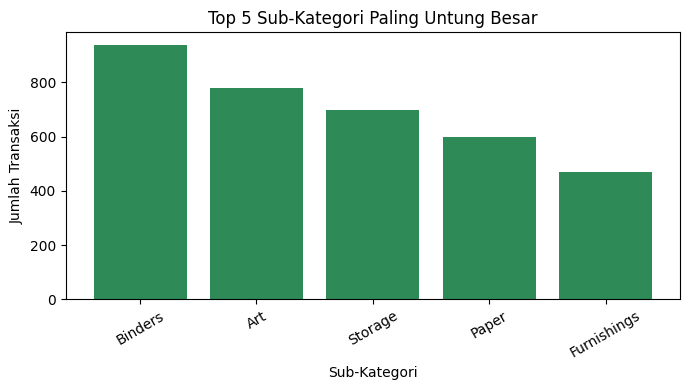

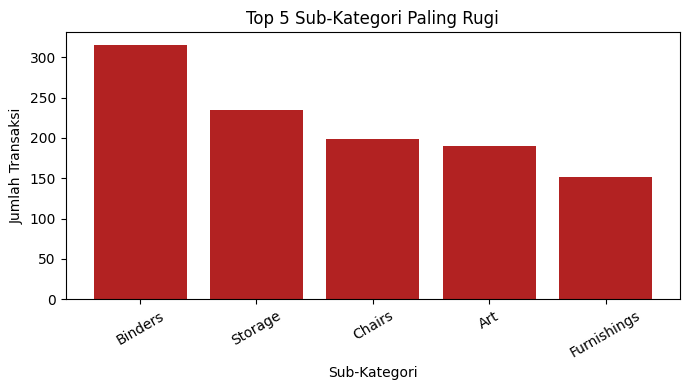

In [ ]:

# Ambil 5 subkategori teratas untuk masing-masing
top_untung = kategori_combined.sort_values(by='Jumlah Untung Besar', ascending=False).head(5)
top_rugi = kategori_combined.sort_values(by='Jumlah Rugi', ascending=False).head(5)

# === Visualisasi Sub-Kategori Untung Besar ===
plt.figure(figsize=(7, 4))
plt.bar(top_untung['sub_category'], top_untung['Jumlah Untung Besar'], color='seagreen')
plt.title('Top 5 Sub-Kategori Paling Untung Besar')
plt.xlabel('Sub-Kategori')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# === Visualisasi Sub-Kategori Paling Rugi ===
plt.figure(figsize=(7, 4))
plt.bar(top_rugi['sub_category'], top_rugi['Jumlah Rugi'], color='firebrick')
plt.title('Top 5 Sub-Kategori Paling Rugi')
plt.xlabel('Sub-Kategori')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
# Hindari warning: salin dataframe dulu
binders_df = binders_df.copy()

# Tambahkan kolom dari data asli
binders_df.loc[:, 'discount'] = df.loc[binders_df.index, 'discount']
binders_df.loc[:, 'shipping_cost'] = df.loc[binders_df.index, 'shipping_cost']

# Filter berdasarkan prediksi
binders_untung_besar = binders_df[binders_df['Prediksi Profit'] == 'Untung Besar']
binders_rugi = binders_df[binders_df['Prediksi Profit'] == 'Rugi']

# Hitung rata-rata
avg_untung = binders_untung_besar[['discount', 'shipping_cost']].mean().rename('Untung Besar')
avg_rugi = binders_rugi[['discount', 'shipping_cost']].mean().rename('Rugi')

# Gabung hasil
binders_summary = pd.concat([avg_untung, avg_rugi], axis=1)

# Tampilkan
print("=== Rata-rata Diskon & Shipping Cost untuk Binders ===")
print(binders_summary)



=== Rata-rata Diskon & Shipping Cost untuk Binders ===
               Untung Besar      Rugi
discount           0.038156  0.634825
shipping_cost      5.996386  5.384508


In [ ]:
# Buat subset data khusus sub-kategori Storage
storage_df = decoded_df[decoded_df['sub_category'] == 'Storage'].copy()

# Tambahkan kolom discount dan shipping_cost asli dari df awal
storage_df['discount'] = df.loc[storage_df.index, 'discount']
storage_df['shipping_cost'] = df.loc[storage_df.index, 'shipping_cost']

# Pisahkan berdasarkan prediksi
storage_untung_besar = storage_df[storage_df['Prediksi Profit'] == 'Untung Besar']
storage_rugi = storage_df[storage_df['Prediksi Profit'] == 'Rugi']

# Hitung rata-rata
avg_untung = storage_untung_besar[['discount', 'shipping_cost']].mean().rename('Untung Besar')
avg_rugi = storage_rugi[['discount', 'shipping_cost']].mean().rename('Rugi')

# Gabungkan hasil
storage_summary = pd.concat([avg_untung, avg_rugi], axis=1)

# Tampilkan
print("=== Rata-rata Diskon & Shipping Cost untuk Storage ===")
print(storage_summary)

=== Rata-rata Diskon & Shipping Cost untuk Storage ===
               Untung Besar       Rugi
discount           0.042798   0.454316
shipping_cost     16.237446  19.351154


In [83]:
# Buat subset data khusus sub-kategori Art
art_df = decoded_df[decoded_df['sub_category'] == 'Art'].copy()

# Tambahkan kolom discount dan shipping_cost asli dari df awal
art_df['discount'] = df.loc[art_df.index, 'discount']
art_df['shipping_cost'] = df.loc[art_df.index, 'shipping_cost']

# Pisahkan berdasarkan prediksi profit
art_untung_besar = art_df[art_df['Prediksi Profit'] == 'Untung Besar']
art_rugi = art_df[art_df['Prediksi Profit'] == 'Rugi']

# Hitung rata-rata untuk masing-masing kondisi
avg_untung = art_untung_besar[['discount', 'shipping_cost']].mean().rename('Untung Besar')
avg_rugi = art_rugi[['discount', 'shipping_cost']].mean().rename('Rugi')

# Gabungkan ke dalam satu tabel ringkasan
art_summary = pd.concat([avg_untung, avg_rugi], axis=1)

# Tampilkan hasil
print("=== Rata-rata Diskon & Shipping Cost untuk Sub-Category: Art ===")
print(art_summary)


=== Rata-rata Diskon & Shipping Cost untuk Sub-Category: Art ===
               Untung Besar      Rugi
discount           0.024031  0.513316
shipping_cost      9.405854  5.518684


In [ ]:
# Buat subset data khusus sub-kategori Storage
storage_df = decoded_df[decoded_df['sub_category'] == 'Storage'].copy()

# Tambahkan kolom discount dan shipping_cost asli dari df awal
storage_df['discount'] = df.loc[storage_df.index, 'discount']
storage_df['shipping_cost'] = df.loc[storage_df.index, 'shipping_cost']

# Pisahkan berdasarkan prediksi
storage_untung_besar = storage_df[storage_df['Prediksi Profit'] == 'Untung Besar']
storage_rugi = storage_df[storage_df['Prediksi Profit'] == 'Rugi']

# Hitung rata-rata
avg_untung = storage_untung_besar[['discount', 'shipping_cost']].mean().rename('Untung Besar')
avg_rugi = storage_rugi[['discount', 'shipping_cost']].mean().rename('Rugi')

# Gabungkan hasil
storage_summary = pd.concat([avg_untung, avg_rugi], axis=1)

# Tampilkan
print("=== Rata-rata Diskon & Shipping Cost untuk Storage ===")
print(storage_summary)

=== Rata-rata Diskon & Shipping Cost untuk Storage ===
               Untung Besar       Rugi
discount           0.042798   0.454316
shipping_cost     16.237446  19.351154


In [ ]:
# Hitung jumlah transaksi prediksi profit per region
region_profit = decoded_df.groupby(['region', 'Prediksi Profit']).size().unstack().fillna(0)

# Tambahkan total transaksi per region
region_profit['Total'] = region_profit.sum(axis=1)

# Hitung persentase untung besar dan rugi per region
region_profit['Persen Untung Besar'] = (region_profit['Untung Besar'] / region_profit['Total']) * 100
region_profit['Persen Rugi'] = (region_profit['Rugi'] / region_profit['Total']) * 100

# Urutkan dari yang paling tinggi untung besar
region_profit_sorted = region_profit.sort_values(by='Persen Untung Besar', ascending=False)

region_profit_sorted[['Untung Besar', 'Rugi', 'Persen Untung Besar', 'Persen Rugi']]

Prediksi Profit,Untung Besar,Rugi,Persen Untung Besar,Persen Rugi
region,,,,
Canada,61.0,0.0,91.044776,0.000000
West,564.0,51.0,86.635945,7.834101
Caribbean,264.0,73.0,73.537604,20.334262
East,415.0,105.0,72.552448,18.356643
Africa,645.0,194.0,69.654428,20.950324
North,636.0,180.0,68.094218,19.271949
North Asia,318.0,45.0,67.803838,9.594883
Central,1497.0,477.0,67.615176,21.544715
South,863.0,328.0,65.577508,24.924012


In [ ]:
# SHIPPING COST BIN vs PREDIKSI PROFIT
shipping_vs_profit = decoded_df.groupby(['shipping_cost_bin', 'Prediksi Profit']).size().unstack().fillna(0)
shipping_vs_profit['Total'] = shipping_vs_profit.sum(axis=1)
shipping_vs_profit['Persen Rugi'] = (shipping_vs_profit['Rugi'] / shipping_vs_profit['Total']) * 100
shipping_vs_profit['Persen Untung Besar'] = (shipping_vs_profit['Untung Besar'] / shipping_vs_profit['Total']) * 100

# ORDER PRIORITY vs PREDIKSI PROFIT
priority_vs_profit = decoded_df.groupby(['order_priority', 'Prediksi Profit']).size().unstack().fillna(0)
priority_vs_profit['Total'] = priority_vs_profit.sum(axis=1)
priority_vs_profit['Persen Rugi'] = (priority_vs_profit['Rugi'] / priority_vs_profit['Total']) * 100
priority_vs_profit['Persen Untung Besar'] = (priority_vs_profit['Untung Besar'] / priority_vs_profit['Total']) * 100

# QUANTITY BIN vs PREDIKSI PROFIT
quantity_vs_profit = decoded_df.groupby(['quantity_bin', 'Prediksi Profit']).size().unstack().fillna(0)
quantity_vs_profit['Total'] = quantity_vs_profit.sum(axis=1)
quantity_vs_profit['Persen Rugi'] = (quantity_vs_profit['Rugi'] / quantity_vs_profit['Total']) * 100
quantity_vs_profit['Persen Untung Besar'] = (quantity_vs_profit['Untung Besar'] / quantity_vs_profit['Total']) * 100

# CATEGORY vs PREDIKSI PROFIT
category_vs_profit = decoded_df.groupby(['category', 'Prediksi Profit']).size().unstack().fillna(0)
category_vs_profit['Total'] = category_vs_profit.sum(axis=1)
category_vs_profit['Persen Rugi'] = (category_vs_profit['Rugi'] / category_vs_profit['Total']) * 100
category_vs_profit['Persen Untung Besar'] = (category_vs_profit['Untung Besar'] / category_vs_profit['Total']) * 100

# Gabungkan semua insight dalam dictionary
feature_breakdown = {
    "Shipping Cost Bin": shipping_vs_profit,
    "Order Priority": priority_vs_profit,
    "Quantity Bin": quantity_vs_profit,
    "Category": category_vs_profit
}

feature_breakdown

C:\Users\71485\AppData\Local\Temp\ipykernel_28004\1392959137.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shipping_vs_profit = decoded_df.groupby(['shipping_cost_bin', 'Prediksi Profit']).size().unstack().fillna(0)
C:\Users\71485\AppData\Local\Temp\ipykernel_28004\1392959137.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantity_vs_profit = decoded_df.groupby(['quantity_bin', 'Prediksi Profit']).size().unstack().fillna(0)


{'Shipping Cost Bin': Prediksi Profit    Rugi  Untung Besar  Untung Kecil  Total  Persen Rugi  \
 shipping_cost_bin                                                         
 Murah              1507          4230             4   5741    26.249782   
 Sedang              598          2410           133   3141    19.038523   
 Mahal               241           198           937   1376    17.514535   
 
 Prediksi Profit    Persen Untung Besar  
 shipping_cost_bin                       
 Murah                        73.680543  
 Sedang                       76.727157  
 Mahal                        14.389535  ,
 'Order Priority': Prediksi Profit  Rugi  Untung Besar  Untung Kecil  Total  Persen Rugi  \
 order_priority                                                          
 Critical          194           514            98    806    24.069479   
 High              695          2009           382   3086    22.521063   
 Low               118           347            38    503    23.459245  

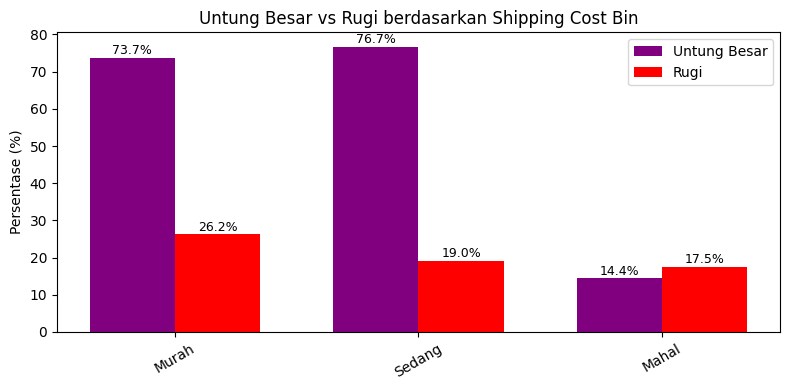

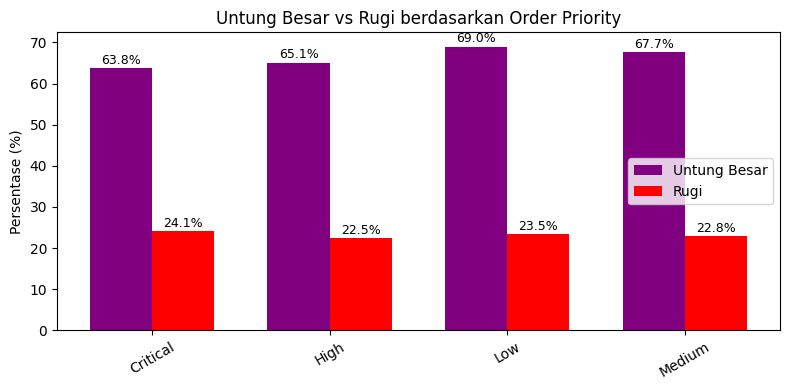

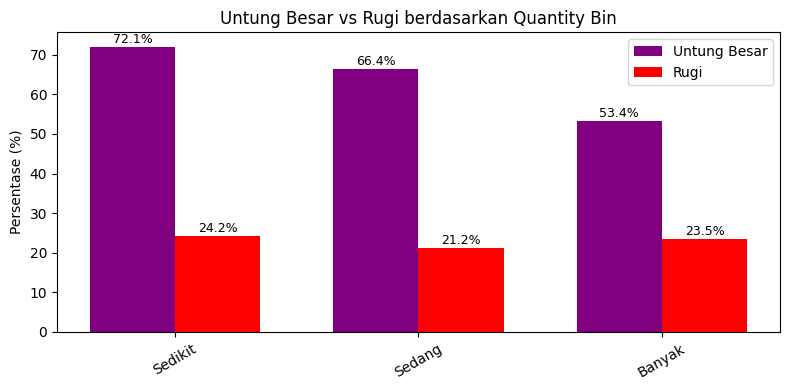

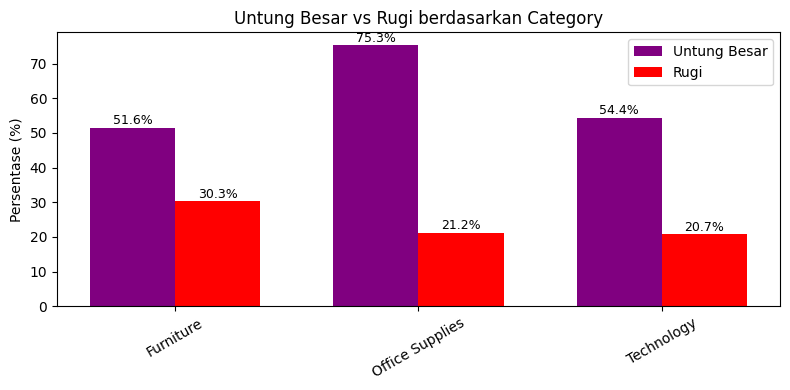

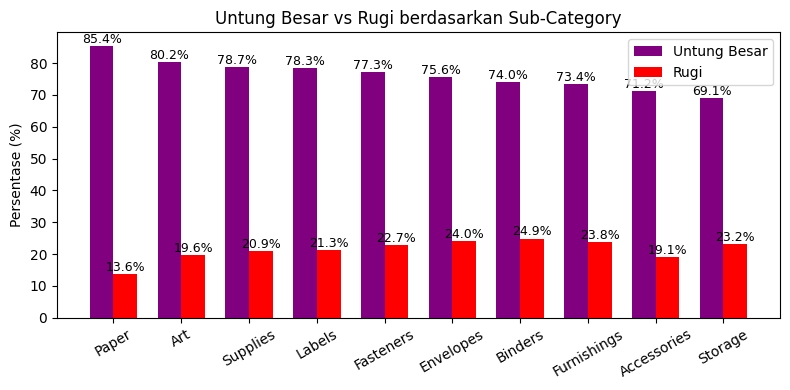

C:\Users\71485\AppData\Local\Temp\ipykernel_28004\3774084532.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_bin_vs_profit = decoded_df.groupby(['discount_bin', 'Prediksi Profit']).size().unstack().fillna(0)


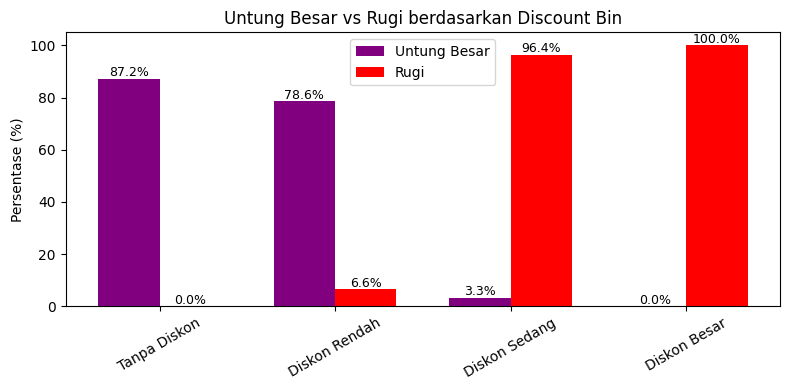

In [ ]:
# Fungsi grafik dengan label dan warna custom
def bar_chart_with_labels(data, title, color1='purple', color2='red'):
    labels = data.index.tolist()
    untung = data['Persen Untung Besar'].values
    rugi = data['Persen Rugi'].values

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8, 4))
    bars1 = plt.bar(x - width/2, untung, width=width, label='Untung Besar', color=color1)
    bars2 = plt.bar(x + width/2, rugi, width=width, label='Rugi', color=color2)

    # Tambahkan label angka di atas batang
    for bar in bars1:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9)
    for bar in bars2:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9)

    plt.xticks(x, labels, rotation=30)
    plt.ylabel('Persentase (%)')
    plt.title(f'Untung Besar vs Rugi berdasarkan {title}')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Tampilkan grafik satu per satu
bar_chart_with_labels(shipping_vs_profit, 'Shipping Cost Bin')
bar_chart_with_labels(priority_vs_profit, 'Order Priority')
bar_chart_with_labels(quantity_vs_profit, 'Quantity Bin')
bar_chart_with_labels(category_vs_profit, 'Category')

# Tambahan: Sub-Category dan Discount Bin
sub_category_vs_profit = decoded_df.groupby(['sub_category', 'Prediksi Profit']).size().unstack().fillna(0)
sub_category_vs_profit['Total'] = sub_category_vs_profit.sum(axis=1)
sub_category_vs_profit['Persen Untung Besar'] = (sub_category_vs_profit['Untung Besar'] / sub_category_vs_profit['Total']) * 100
sub_category_vs_profit['Persen Rugi'] = (sub_category_vs_profit['Rugi'] / sub_category_vs_profit['Total']) * 100

bar_chart_with_labels(sub_category_vs_profit.sort_values(by='Persen Untung Besar', ascending=False).head(10), 'Sub-Category')

discount_bin_vs_profit = decoded_df.groupby(['discount_bin', 'Prediksi Profit']).size().unstack().fillna(0)
discount_bin_vs_profit['Total'] = discount_bin_vs_profit.sum(axis=1)
discount_bin_vs_profit['Persen Untung Besar'] = (discount_bin_vs_profit['Untung Besar'] / discount_bin_vs_profit['Total']) * 100
discount_bin_vs_profit['Persen Rugi'] = (discount_bin_vs_profit['Rugi'] / discount_bin_vs_profit['Total']) * 100

bar_chart_with_labels(discount_bin_vs_profit, 'Discount Bin')

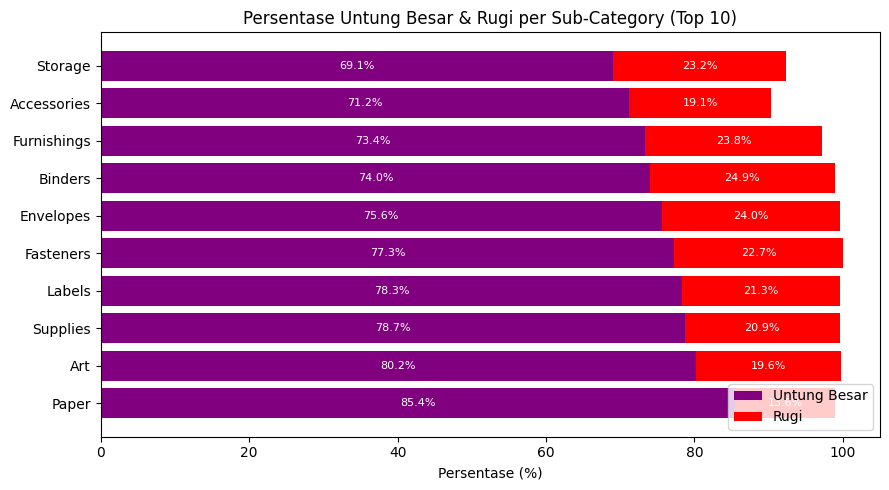

In [ ]:
# SUB-CATEGORY: Stacked Horizontal Bar dengan Label
sub_category_vs_profit = decoded_df.groupby(['sub_category', 'Prediksi Profit']).size().unstack().fillna(0)
sub_category_vs_profit['Total'] = sub_category_vs_profit.sum(axis=1)
sub_category_vs_profit['Persen Untung Besar'] = (sub_category_vs_profit['Untung Besar'] / sub_category_vs_profit['Total']) * 100
sub_category_vs_profit['Persen Rugi'] = (sub_category_vs_profit['Rugi'] / sub_category_vs_profit['Total']) * 100

# Ambil 10 sub-kategori terbaik
sub_sorted = sub_category_vs_profit.sort_values(by='Persen Untung Besar', ascending=False).head(10)

plt.figure(figsize=(9, 5))
plt.barh(sub_sorted.index, sub_sorted['Persen Untung Besar'], color='purple', label='Untung Besar')
plt.barh(sub_sorted.index, sub_sorted['Persen Rugi'], left=sub_sorted['Persen Untung Besar'], color='red', label='Rugi')

# Tambahkan label angka
for i, (u, r) in enumerate(zip(sub_sorted['Persen Untung Besar'], sub_sorted['Persen Rugi'])):
    plt.text(u / 2, i, f"{u:.1f}%", va='center', ha='center', color='white', fontsize=8)
    plt.text(u + r / 2, i, f"{r:.1f}%", va='center', ha='center', color='white', fontsize=8)

plt.xlabel('Persentase (%)')
plt.title('Persentase Untung Besar & Rugi per Sub-Category (Top 10)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
